# Notebook 01 — Q-learning CVRP Experiments

Ce notebook exécute la baseline **Q-learning tabulaire** pour le CVRP.

Objectifs :
- utiliser le même environnement CVRP que les autres modèles RL ;
- produire les mêmes métriques finales que les heuristiques et POMO ;
- entraîner sur plusieurs `seeds` ;
- sauvegarder les métriques d'entraînement ;
- générer les courbes d'apprentissage ;
- générer les cartes des routes obtenues.

Sorties principales :
- `results/q_learning/experiments_q_learning.csv`
- `results/q_learning/training_metrics_q_learning.csv`
- `results/q_learning/summary_q_learning_by_seed.csv`
- `results/q_learning/figures/*.png`
- `results/q_learning/routes/*.png`

In [1]:
from pathlib import Path
import sys
import random
import json
from time import perf_counter
from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

# Permet d'importer src/ même si le notebook est lancé depuis notebooks/
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    ROOT_DIR = CURRENT_DIR.parent
else:
    ROOT_DIR = CURRENT_DIR

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.cvrp.data.parser import load_cvrp_instance
from src.cvrp.rl.env import CVRPEnv
from src.cvrp.rl.q_learning_agent import QLearningAgent
from src.cvrp.core.metrics import FINAL_RESULT_COLUMNS, build_final_result_row
from src.cvrp.core.validation import validate_solution
from src.cvrp.visualization.plot_routes import plot_solution_routes

print("ROOT_DIR :", ROOT_DIR)

ROOT_DIR : f:\code\projects\tfc\export_windows


## 1. Configuration expérimentale

Pour un test rapide, réduis `episodes` et `seeds`.

Pour les résultats du mémoire :
- garder au moins 5 seeds ;
- utiliser au moins 1000 épisodes ;
- ajouter les autres instances dans `instance_paths` et `reference_costs`.

In [2]:
CONFIG = {
    "instance_paths": [
        "data/instances/A-n32-k5.vrp",
        "data/instances/A-n37-k5.vrp",
        "data/instances/A-n39-k6.vrp",
    ],

    "reference_costs": {
        "A-n32-k5": 784,
        "A-n37-k5": 669,
        "A-n39-k6": 831,

    },

    # Pour le mémoire final : au moins 5 seeds.
    "seeds": [42, 43, 44, 45, 46],

    # Pour test rapide : 100 ou 200.
    # Pour résultat final : 1000 ou plus.
    "episodes": 1000,

    "max_steps": 500,

    # Hyperparamètres Q-learning
    "learning_rate": 0.1,
    "gamma": 0.95,
    "epsilon": 1.0,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.995,

    # Récompenses
    "invalid_action_penalty": -1000.0,
    "incomplete_solution_penalty": -5000.0,
    "completion_bonus": 100.0,
    "distance_reward_scale": 1.0,

    # Sorties
    "output_dir": "results/q_learning",
    "figures_dir": "results/q_learning/figures",
    "routes_dir": "results/q_learning/routes",
}

for key in ["output_dir", "figures_dir", "routes_dir"]:
    (ROOT_DIR / CONFIG[key]).mkdir(parents=True, exist_ok=True)

CONFIG

{'instance_paths': ['data/instances/A-n32-k5.vrp',
  'data/instances/A-n37-k5.vrp',
  'data/instances/A-n39-k6.vrp'],
 'reference_costs': {'A-n32-k5': 784, 'A-n37-k5': 669, 'A-n39-k6': 831},
 'seeds': [42, 43, 44, 45, 46],
 'episodes': 1000,
 'max_steps': 500,
 'learning_rate': 0.1,
 'gamma': 0.95,
 'epsilon': 1.0,
 'epsilon_min': 0.05,
 'epsilon_decay': 0.995,
 'invalid_action_penalty': -1000.0,
 'incomplete_solution_penalty': -5000.0,
 'completion_bonus': 100.0,
 'distance_reward_scale': 1.0,
 'output_dir': 'results/q_learning',
 'figures_dir': 'results/q_learning/figures',
 'routes_dir': 'results/q_learning/routes'}

## 2. Fonctions utilitaires

Ces fonctions assurent :
- l'entraînement épisode par épisode ;
- l'évaluation greedy finale ;
- la sauvegarde des routes ;
- le calcul des métriques compatibles avec le tableau final.

In [3]:
def count_capacity_violations(instance, validation):
    return sum(1 for load in validation.route_loads if load > instance.capacity)


def train_one_episode(env, agent, episode, seed, instance_name, max_steps=500):
    """
    Entraîne l'agent pendant un épisode.
    """
    env.reset()

    total_reward = 0.0
    done = False
    steps = 0

    while not done and steps < max_steps:
        state = env.get_q_learning_state()
        valid_actions = env.get_valid_actions()

        if not valid_actions:
            break

        action = agent.select_action(
            state=state,
            valid_actions=valid_actions,
            greedy=False,
        )

        _, reward, done, info = env.step(action)

        next_state = env.get_q_learning_state()
        next_valid_actions = env.get_valid_actions() if not done else []

        agent.update(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            next_valid_actions=next_valid_actions,
            done=done,
        )

        total_reward += reward
        steps += 1

    agent.decay_epsilon()

    routes = env.get_solution()
    validation = validate_solution(env.instance, routes)

    return {
        "instance": instance_name,
        "seed": seed,
        "episode": episode,
        "reward": total_reward,
        "cost": validation.cost,
        "gap_percent": validation.gap_percent,
        "is_valid": validation.is_valid,
        "routes": len(routes),
        "missing_customers_count": len(validation.missing_customers),
        "duplicated_customers_count": len(validation.duplicated_customers),
        "capacity_violations_count": count_capacity_violations(env.instance, validation),
        "steps": steps,
        "epsilon": agent.epsilon,
        "q_table_size": agent.q_table_size(),
    }


def select_greedy_action_with_fallback(env, agent):
    """
    Évaluation greedy.

    Si l'état est inconnu ou si toutes les valeurs Q sont nulles,
    on choisit le client valide le plus proche.
    Cela évite qu'une évaluation soit totalement aléatoire
    sur un état jamais appris.
    """
    state = env.get_q_learning_state()
    valid_actions = env.get_valid_actions()

    if not valid_actions:
        return None

    q_values = agent.q_table[state]
    values = [q_values[action] for action in valid_actions]

    all_values_equal = len(set(values)) == 1

    if all_values_equal and values[0] == 0:
        depot = env.instance.depot
        customer_actions = [a for a in valid_actions if a != depot]

        if customer_actions:
            return min(
                customer_actions,
                key=lambda customer: env.instance.distance(env.current_node, customer),
            )

        return depot

    return agent.select_action(
        state=state,
        valid_actions=valid_actions,
        greedy=True,
    )


def evaluate_agent(env, agent, max_steps=500):
    """
    Évalue l'agent en mode greedy, sans exploration.
    """
    env.reset()

    total_reward = 0.0
    done = False
    steps = 0

    while not done and steps < max_steps:
        action = select_greedy_action_with_fallback(env, agent)

        if action is None:
            break

        _, reward, done, info = env.step(action)

        total_reward += reward
        steps += 1

    routes = env.get_solution()
    validation = validate_solution(env.instance, routes)

    evaluation = {
        "reward": total_reward,
        "cost": validation.cost,
        "gap_percent": validation.gap_percent,
        "is_valid": validation.is_valid,
        "routes": len(routes),
        "missing_customers_count": len(validation.missing_customers),
        "duplicated_customers_count": len(validation.duplicated_customers),
        "capacity_violations_count": count_capacity_violations(env.instance, validation),
        "steps": steps,
    }

    return routes, evaluation


def serialize_solution(instance, method_name, seed, routes):
    """
    Prépare une solution pour sauvegarde JSON.
    """
    validation = validate_solution(instance, routes)

    return {
        "instance": instance.name,
        "method": method_name,
        "seed": seed,
        "cost": validation.cost,
        "gap_percent": validation.gap_percent,
        "is_valid": validation.is_valid,
        "routes_count": len(routes),
        "route_loads": validation.route_loads,
        "routes": routes,
        "errors": validation.errors,
        "warnings": validation.warnings,
    }

## 3. Entraînement multi-instances et multi-seeds

Cette cellule exécute les expériences Q-learning et sauvegarde :
- l'agent de chaque seed ;
- la carte de route de chaque seed ;
- les métriques d'entraînement épisode par épisode ;
- la ligne finale comparable aux autres méthodes.

In [4]:
all_training_metrics = []
all_final_rows = []
all_serialized_solutions = []

for instance_path_str in CONFIG["instance_paths"]:
    instance_path = ROOT_DIR / instance_path_str
    instance_name = instance_path.stem

    if not instance_path.exists():
        print(f"[SKIP] Instance introuvable : {instance_path}")
        continue

    reference_cost = CONFIG["reference_costs"].get(instance_name)

    instance = load_cvrp_instance(
        instance_path,
        reference_cost=reference_cost,
    )

    print("\n" + "=" * 90)
    print("Instance :", instance.name)
    print("Clients :", instance.customer_count)
    print("Véhicules :", instance.vehicle_count)
    print("Capacité :", instance.capacity)
    print("Référence :", instance.reference_cost)
    print("=" * 90)

    for seed in CONFIG["seeds"]:
        random.seed(seed)

        env = CVRPEnv(
            instance=instance,
            max_routes=instance.vehicle_count,
            invalid_action_penalty=CONFIG["invalid_action_penalty"],
            incomplete_solution_penalty=CONFIG["incomplete_solution_penalty"],
            completion_bonus=CONFIG["completion_bonus"],
            distance_reward_scale=CONFIG["distance_reward_scale"],
        )

        agent = QLearningAgent(
            learning_rate=CONFIG["learning_rate"],
            gamma=CONFIG["gamma"],
            epsilon=CONFIG["epsilon"],
            epsilon_min=CONFIG["epsilon_min"],
            epsilon_decay=CONFIG["epsilon_decay"],
            seed=seed,
        )

        print(f"\nSeed {seed} | entraînement Q-learning")

        train_start = perf_counter()

        for episode in range(1, CONFIG["episodes"] + 1):
            metrics = train_one_episode(
                env=env,
                agent=agent,
                episode=episode,
                seed=seed,
                instance_name=instance.name,
                max_steps=CONFIG["max_steps"],
            )

            all_training_metrics.append(metrics)

            if episode == 1 or episode % 100 == 0 or episode == CONFIG["episodes"]:
                print(
                    f"Episode {episode:04d} | "
                    f"reward={metrics['reward']:.2f} | "
                    f"cost={metrics['cost']} | "
                    f"gap={metrics['gap_percent']} | "
                    f"valid={metrics['is_valid']} | "
                    f"epsilon={metrics['epsilon']:.4f} | "
                    f"q_states={metrics['q_table_size']}"
                )

        train_time_sec = perf_counter() - train_start

        inference_start = perf_counter()
        routes, evaluation = evaluate_agent(
            env=env,
            agent=agent,
            max_steps=CONFIG["max_steps"],
        )
        inference_time_sec = perf_counter() - inference_start

        final_row = build_final_result_row(
            instance=instance,
            method="Q-learning RL",
            category="rl_baseline",
            routes=routes,
            seed=seed,
            train_time_sec=train_time_sec,
            inference_time_sec=inference_time_sec,
            postprocess_time_sec=0.0,
            episodes=CONFIG["episodes"],
            notes=(
                "Baseline RL tabulaire avec état discret "
                "(noeud courant, capacité restante, clients visités, routes utilisées)."
            ),
        )

        all_final_rows.append(final_row)

        print("\nÉvaluation finale seed", seed)
        pprint(final_row)

        # Sauvegarde agent
        agent_output_path = (
            ROOT_DIR
            / CONFIG["output_dir"]
            / f"{instance.name}_q_learning_seed_{seed}.json"
        )
        agent.save(agent_output_path)

        # Sauvegarde carte
        route_output_path = (
            ROOT_DIR
            / CONFIG["routes_dir"]
            / f"{instance.name}_q_learning_seed_{seed}.png"
        )

        plot_solution_routes(
            instance=instance,
            routes=routes,
            title=f"Q-learning RL | seed={seed}",
            output_path=route_output_path,
            show_node_labels=True,
            show_route_labels=True,
        )

        # Sauvegarde routes JSON
        all_serialized_solutions.append(
            serialize_solution(instance, "Q-learning RL", seed, routes)
        )

        print("Agent sauvegardé :", agent_output_path)
        print("Carte sauvegardée :", route_output_path)

print("\nExpériences terminées.")
print("Lignes training :", len(all_training_metrics))
print("Lignes finales :", len(all_final_rows))


Instance : A-n32-k5
Clients : 31
Véhicules : 5
Capacité : 100
Référence : 784

Seed 42 | entraînement Q-learning
Episode 0001 | reward=-7034.00 | cost=2034.0 | gap=159.4387755102041 | valid=False | epsilon=0.9950 | q_states=35
Episode 0100 | reward=-7020.00 | cost=2020.0 | gap=157.6530612244898 | valid=False | epsilon=0.6058 | q_states=3195
Episode 0200 | reward=-6819.00 | cost=1819.0 | gap=132.01530612244898 | valid=False | epsilon=0.3670 | q_states=6306
Episode 0300 | reward=-1997.00 | cost=2097.0 | gap=167.47448979591837 | valid=True | epsilon=0.2223 | q_states=9413
Episode 0400 | reward=-7059.00 | cost=2059.0 | gap=162.62755102040816 | valid=False | epsilon=0.1347 | q_states=12439
Episode 0500 | reward=-2166.00 | cost=2266.0 | gap=189.03061224489795 | valid=True | epsilon=0.0816 | q_states=15471
Episode 0600 | reward=-6662.00 | cost=1662.0 | gap=111.98979591836735 | valid=False | epsilon=0.0500 | q_states=18516
Episode 0700 | reward=-6855.00 | cost=1855.0 | gap=136.60714285714286 

## 4. Sauvegarde des CSV

Les résultats finaux utilisent les mêmes colonnes que les heuristiques et que POMO.

In [5]:
training_df = pd.DataFrame(all_training_metrics)
experiments_df = pd.DataFrame(all_final_rows)

if experiments_df.empty:
    raise RuntimeError("Aucun résultat final généré. Vérifie les chemins des instances.")

# Réordonner le CSV final avec les colonnes standardisées.
experiments_df = experiments_df[FINAL_RESULT_COLUMNS]

training_output_path = ROOT_DIR / CONFIG["output_dir"] / "training_metrics_q_learning.csv"
experiments_output_path = ROOT_DIR / CONFIG["output_dir"] / "experiments_q_learning.csv"
solutions_output_path = ROOT_DIR / CONFIG["routes_dir"] / "q_learning_routes.json"

training_df.to_csv(training_output_path, index=False, encoding="utf-8")
experiments_df.to_csv(experiments_output_path, index=False, encoding="utf-8")

with solutions_output_path.open("w", encoding="utf-8") as file:
    json.dump(all_serialized_solutions, file, indent=2, ensure_ascii=False)

print("Training metrics :", training_output_path)
print("Experiments :", experiments_output_path)
print("Routes JSON :", solutions_output_path)

display(training_df.head())
display(experiments_df)

Training metrics : f:\code\projects\tfc\export_windows\results\q_learning\training_metrics_q_learning.csv
Experiments : f:\code\projects\tfc\export_windows\results\q_learning\experiments_q_learning.csv
Routes JSON : f:\code\projects\tfc\export_windows\results\q_learning\routes\q_learning_routes.json


,instance,seed,episode,reward,cost,gap_percent,is_valid,routes,missing_customers_count,duplicated_customers_count,capacity_violations_count,steps,epsilon,q_table_size
0,A-n32-k5,42,1,-7034.0,2034.0,159.438776,False,5,1,0,0,35,0.995000,35
1,A-n32-k5,42,2,-6795.0,1795.0,128.954082,False,5,3,0,0,33,0.990025,67
2,A-n32-k5,42,3,-7226.0,2226.0,183.928571,False,5,1,0,0,35,0.985075,101
3,A-n32-k5,42,4,-7158.0,2158.0,175.255102,False,5,2,0,0,34,0.980150,134
4,A-n32-k5,42,5,-6975.0,1975.0,151.913265,False,5,2,0,0,34,0.975249,167


,instance,method,category,seed,cost,reference_cost,gap_percent,routes,vehicle_count,is_valid,missing_customers_count,duplicated_customers_count,capacity_violations_count,train_time_sec,inference_time_sec,postprocess_time_sec,total_time_sec,episodes,notes
0,A-n32-k5,Q-learning RL,rl_baseline,42,1344.0,784,71.428571,5,5,True,0,0,0,5.995402,0.005699,0.0,6.001100,1000,Baseline RL tabulaire avec état discret (noeud...
1,A-n32-k5,Q-learning RL,rl_baseline,43,1310.0,784,67.091837,5,5,True,0,0,0,7.325541,0.004866,0.0,7.330407,1000,Baseline RL tabulaire avec état discret (noeud...
2,A-n32-k5,Q-learning RL,rl_baseline,44,1096.0,784,39.795918,5,5,True,0,0,0,5.478784,0.006649,0.0,5.485433,1000,Baseline RL tabulaire avec état discret (noeud...
3,A-n32-k5,Q-learning RL,rl_baseline,45,1237.0,784,57.780612,5,5,True,0,0,0,6.640100,0.006452,0.0,6.646552,1000,Baseline RL tabulaire avec état discret (noeud...
4,A-n32-k5,Q-learning RL,rl_baseline,46,1220.0,784,55.612245,5,5,True,0,0,0,5.561830,0.005146,0.0,5.566975,1000,Baseline RL tabulaire avec état discret (noeud...
5,A-n37-k5,Q-learning RL,rl_baseline,42,1025.0,669,53.213752,5,5,True,0,0,0,6.191259,0.004461,0.0,6.195720,1000,Baseline RL tabulaire avec état discret (noeud...
6,A-n37-k5,Q-learning RL,rl_baseline,43,1022.0,669,52.765321,5,5,True,0,0,0,6.210727,0.006970,0.0,6.217697,1000,Baseline RL tabulaire avec état discret (noeud...
7,A-n37-k5,Q-learning RL,rl_baseline,44,1104.0,669,65.022422,5,5,True,0,0,0,16.301388,0.023171,0.0,16.324559,1000,Baseline RL tabulaire avec état discret (noeud...
8,A-n37-k5,Q-learning RL,rl_baseline,45,999.0,669,49.327354,5,5,True,0,0,0,21.651798,0.010634,0.0,21.662432,1000,Baseline RL tabulaire avec état discret (noeud...
9,A-n37-k5,Q-learning RL,rl_baseline,46,946.0,669,41.405082,5,5,False,1,0,0,19.973938,0.023777,0.0,19.997716,1000,Baseline RL tabulaire avec état discret (noeud...


## 5. Résumé statistique par instance

Cette synthèse servira dans le mémoire pour présenter :
- moyenne ;
- écart-type ;
- minimum ;
- maximum ;
- taux de validité ;
- temps moyen.

In [6]:
summary_by_seed = experiments_df[
    [
        "instance",
        "method",
        "seed",
        "cost",
        "reference_cost",
        "gap_percent",
        "routes",
        "is_valid",
        "train_time_sec",
        "inference_time_sec",
        "total_time_sec",
    ]
].copy()

display(summary_by_seed)

summary_stats = experiments_df.groupby(["instance", "method"]).agg(
    cost_mean=("cost", "mean"),
    cost_std=("cost", "std"),
    cost_min=("cost", "min"),
    cost_max=("cost", "max"),
    gap_mean=("gap_percent", "mean"),
    gap_std=("gap_percent", "std"),
    valid_rate=("is_valid", "mean"),
    train_time_mean=("train_time_sec", "mean"),
    inference_time_mean=("inference_time_sec", "mean"),
    total_time_mean=("total_time_sec", "mean"),
).reset_index()

summary_stats_output_path = ROOT_DIR / CONFIG["output_dir"] / "summary_q_learning_by_seed.csv"
summary_stats.to_csv(summary_stats_output_path, index=False, encoding="utf-8")

print("Résumé sauvegardé :", summary_stats_output_path)
display(summary_stats)

,instance,method,seed,cost,reference_cost,gap_percent,routes,is_valid,train_time_sec,inference_time_sec,total_time_sec
0,A-n32-k5,Q-learning RL,42,1344.0,784,71.428571,5,True,5.995402,0.005699,6.001100
1,A-n32-k5,Q-learning RL,43,1310.0,784,67.091837,5,True,7.325541,0.004866,7.330407
2,A-n32-k5,Q-learning RL,44,1096.0,784,39.795918,5,True,5.478784,0.006649,5.485433
3,A-n32-k5,Q-learning RL,45,1237.0,784,57.780612,5,True,6.640100,0.006452,6.646552
4,A-n32-k5,Q-learning RL,46,1220.0,784,55.612245,5,True,5.561830,0.005146,5.566975
5,A-n37-k5,Q-learning RL,42,1025.0,669,53.213752,5,True,6.191259,0.004461,6.195720
6,A-n37-k5,Q-learning RL,43,1022.0,669,52.765321,5,True,6.210727,0.006970,6.217697
7,A-n37-k5,Q-learning RL,44,1104.0,669,65.022422,5,True,16.301388,0.023171,16.324559
8,A-n37-k5,Q-learning RL,45,999.0,669,49.327354,5,True,21.651798,0.010634,21.662432
9,A-n37-k5,Q-learning RL,46,946.0,669,41.405082,5,False,19.973938,0.023777,19.997716


Résumé sauvegardé : f:\code\projects\tfc\export_windows\results\q_learning\summary_q_learning_by_seed.csv


,instance,method,cost_mean,cost_std,cost_min,cost_max,gap_mean,gap_std,valid_rate,train_time_mean,inference_time_mean,total_time_mean
0,A-n32-k5,Q-learning RL,1241.4,95.983332,1096.0,1344.0,58.341837,12.242772,1.0,6.200331,0.005762,6.206093
1,A-n37-k5,Q-learning RL,1019.2,57.006140,946.0,1104.0,52.346786,8.521097,0.8,14.065822,0.013803,14.079625
2,A-n39-k6,Q-learning RL,1117.2,79.269792,1068.0,1256.0,34.440433,9.539085,0.4,10.038216,0.005671,10.043887


## 6. Courbes d'apprentissage

Les courbes sont sauvegardées dans `results/q_learning/figures/`.

Elles répondent à la critique méthodologique sur l'absence d'analyse de convergence.

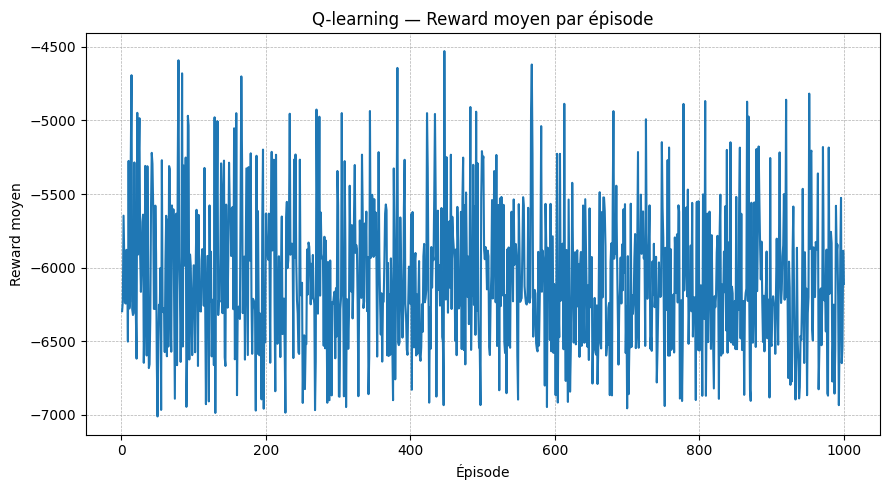

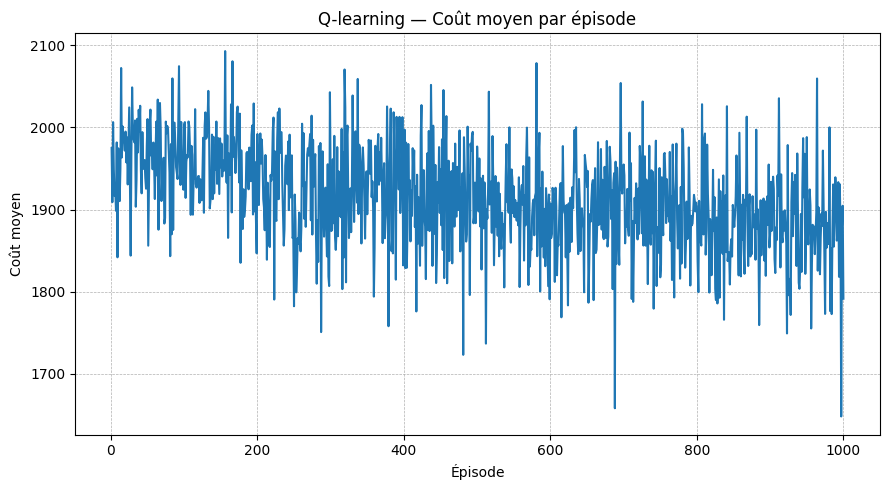

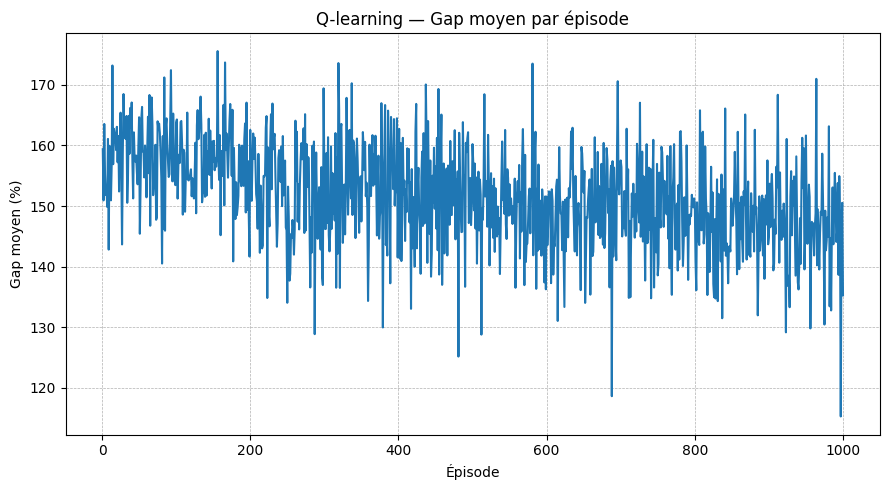

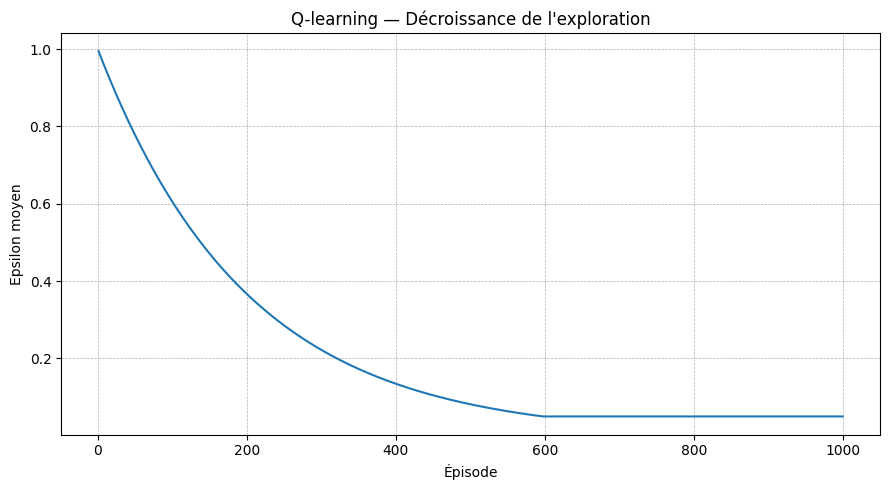

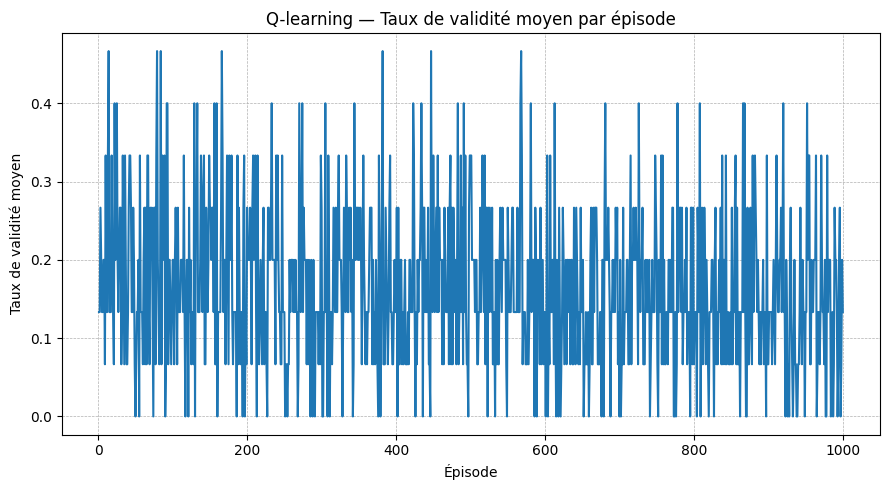

Figures sauvegardées :
- f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_reward_curve.png
- f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_cost_curve.png
- f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_gap_curve.png
- f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_epsilon_curve.png
- f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_valid_rate_curve.png


In [7]:
figures_dir = ROOT_DIR / CONFIG["figures_dir"]
figures_dir.mkdir(parents=True, exist_ok=True)

plot_df = training_df.copy()

# Conversion explicite pour éviter des problèmes si certaines valeurs sont None.
for col in ["reward", "cost", "gap_percent", "epsilon", "is_valid"]:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

# Agrégation par épisode sur toutes les seeds.
episode_mean = plot_df.groupby("episode").agg(
    reward_mean=("reward", "mean"),
    cost_mean=("cost", "mean"),
    gap_mean=("gap_percent", "mean"),
    epsilon_mean=("epsilon", "mean"),
    valid_rate=("is_valid", "mean"),
).reset_index()

# Courbe reward
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["reward_mean"])
plt.xlabel("Épisode")
plt.ylabel("Reward moyen")
plt.title("Q-learning — Reward moyen par épisode")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
reward_path = figures_dir / "q_learning_reward_curve.png"
plt.savefig(reward_path, dpi=200)
plt.show()

# Courbe coût
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["cost_mean"])
plt.xlabel("Épisode")
plt.ylabel("Coût moyen")
plt.title("Q-learning — Coût moyen par épisode")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
cost_path = figures_dir / "q_learning_cost_curve.png"
plt.savefig(cost_path, dpi=200)
plt.show()

# Courbe gap
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["gap_mean"])
plt.xlabel("Épisode")
plt.ylabel("Gap moyen (%)")
plt.title("Q-learning — Gap moyen par épisode")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
gap_path = figures_dir / "q_learning_gap_curve.png"
plt.savefig(gap_path, dpi=200)
plt.show()

# Courbe epsilon
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["epsilon_mean"])
plt.xlabel("Épisode")
plt.ylabel("Epsilon moyen")
plt.title("Q-learning — Décroissance de l'exploration")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
epsilon_path = figures_dir / "q_learning_epsilon_curve.png"
plt.savefig(epsilon_path, dpi=200)
plt.show()

# Courbe taux de validité
plt.figure(figsize=(9, 5))
plt.plot(episode_mean["episode"], episode_mean["valid_rate"])
plt.xlabel("Épisode")
plt.ylabel("Taux de validité moyen")
plt.title("Q-learning — Taux de validité moyen par épisode")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
valid_path = figures_dir / "q_learning_valid_rate_curve.png"
plt.savefig(valid_path, dpi=200)
plt.show()

print("Figures sauvegardées :")
print("-", reward_path)
print("-", cost_path)
print("-", gap_path)
print("-", epsilon_path)
print("-", valid_path)

## 7. Courbes par seed

Ces courbes permettent de visualiser la variabilité du Q-learning selon l'initialisation et l'exploration.

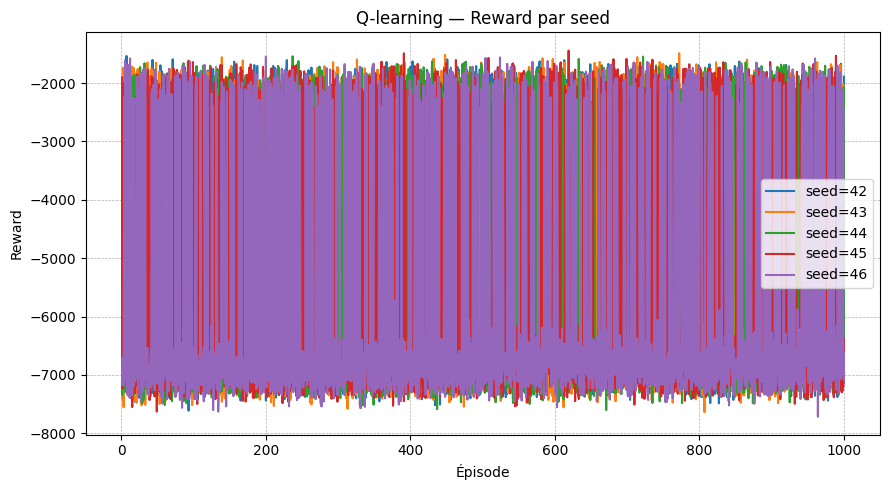

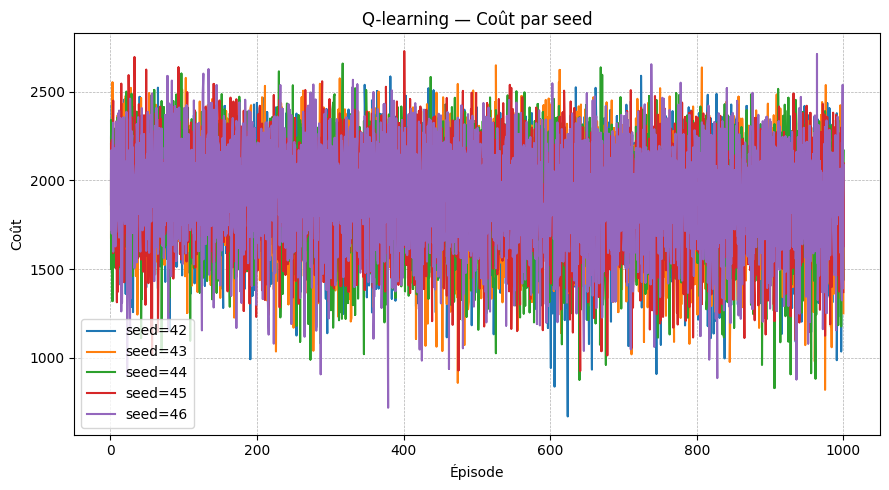

Figures par seed :
- f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_reward_by_seed.png
- f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_cost_by_seed.png


In [8]:
# Reward par seed
plt.figure(figsize=(9, 5))
for seed, seed_df in plot_df.groupby("seed"):
    seed_df = seed_df.sort_values("episode")
    plt.plot(seed_df["episode"], seed_df["reward"], label=f"seed={seed}")

plt.xlabel("Épisode")
plt.ylabel("Reward")
plt.title("Q-learning — Reward par seed")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
reward_seed_path = figures_dir / "q_learning_reward_by_seed.png"
plt.savefig(reward_seed_path, dpi=200)
plt.show()

# Coût par seed
plt.figure(figsize=(9, 5))
for seed, seed_df in plot_df.groupby("seed"):
    seed_df = seed_df.sort_values("episode")
    plt.plot(seed_df["episode"], seed_df["cost"], label=f"seed={seed}")

plt.xlabel("Épisode")
plt.ylabel("Coût")
plt.title("Q-learning — Coût par seed")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.tight_layout()
cost_seed_path = figures_dir / "q_learning_cost_by_seed.png"
plt.savefig(cost_seed_path, dpi=200)
plt.show()

print("Figures par seed :")
print("-", reward_seed_path)
print("-", cost_seed_path)

## 8. Analyse textuelle des résultats Q-learning

Cette cellule produit une interprétation automatique de premier niveau.
Le texte final du mémoire devra être rédigé proprement à partir de ces constats.

In [9]:
for _, row in summary_stats.iterrows():
    print("\n" + "=" * 80)
    print(f"Instance : {row['instance']}")
    print(f"Méthode  : {row['method']}")
    print("=" * 80)

    print(f"Coût moyen      : {row['cost_mean']:.2f}")
    print(f"Écart-type coût : {row['cost_std']:.2f}" if pd.notna(row["cost_std"]) else "Écart-type coût : N/A")
    print(f"Meilleur coût   : {row['cost_min']:.2f}")
    print(f"Pire coût       : {row['cost_max']:.2f}")
    print(f"Gap moyen       : {row['gap_mean']:.2f} %" if pd.notna(row["gap_mean"]) else "Gap moyen       : N/A")
    print(f"Taux validité   : {row['valid_rate'] * 100:.2f} %")
    print(f"Temps entraînement moyen : {row['train_time_mean']:.4f} s")
    print(f"Temps inférence moyen    : {row['inference_time_mean']:.6f} s")
    print(f"Temps total moyen        : {row['total_time_mean']:.4f} s")

print("\nLecture méthodologique :")
print(
    "Q-learning est conservé comme baseline RL simple. "
    "Sa performance doit être comparée aux heuristiques classiques et à POMO, "
    "mais il ne doit pas être présenté comme le modèle RL principal."
)


Instance : A-n32-k5
Méthode  : Q-learning RL
Coût moyen      : 1241.40
Écart-type coût : 95.98
Meilleur coût   : 1096.00
Pire coût       : 1344.00
Gap moyen       : 58.34 %
Taux validité   : 100.00 %
Temps entraînement moyen : 6.2003 s
Temps inférence moyen    : 0.005762 s
Temps total moyen        : 6.2061 s

Instance : A-n37-k5
Méthode  : Q-learning RL
Coût moyen      : 1019.20
Écart-type coût : 57.01
Meilleur coût   : 946.00
Pire coût       : 1104.00
Gap moyen       : 52.35 %
Taux validité   : 80.00 %
Temps entraînement moyen : 14.0658 s
Temps inférence moyen    : 0.013803 s
Temps total moyen        : 14.0796 s

Instance : A-n39-k6
Méthode  : Q-learning RL
Coût moyen      : 1117.20
Écart-type coût : 79.27
Meilleur coût   : 1068.00
Pire coût       : 1256.00
Gap moyen       : 34.44 %
Taux validité   : 40.00 %
Temps entraînement moyen : 10.0382 s
Temps inférence moyen    : 0.005671 s
Temps total moyen        : 10.0439 s

Lecture méthodologique :
Q-learning est conservé comme baseline R

## 9. Checklist de sortie

À la fin de ce notebook, vérifie que les fichiers suivants existent.

In [10]:
expected_outputs = [
    ROOT_DIR / CONFIG["output_dir"] / "experiments_q_learning.csv",
    ROOT_DIR / CONFIG["output_dir"] / "training_metrics_q_learning.csv",
    ROOT_DIR / CONFIG["output_dir"] / "summary_q_learning_by_seed.csv",
    ROOT_DIR / CONFIG["figures_dir"] / "q_learning_reward_curve.png",
    ROOT_DIR / CONFIG["figures_dir"] / "q_learning_cost_curve.png",
    ROOT_DIR / CONFIG["figures_dir"] / "q_learning_gap_curve.png",
    ROOT_DIR / CONFIG["figures_dir"] / "q_learning_epsilon_curve.png",
    ROOT_DIR / CONFIG["figures_dir"] / "q_learning_valid_rate_curve.png",
    ROOT_DIR / CONFIG["routes_dir"] / "q_learning_routes.json",
]

for path in expected_outputs:
    print("[OK]" if path.exists() else "[MANQUANT]", path)

[OK] f:\code\projects\tfc\export_windows\results\q_learning\experiments_q_learning.csv
[OK] f:\code\projects\tfc\export_windows\results\q_learning\training_metrics_q_learning.csv
[OK] f:\code\projects\tfc\export_windows\results\q_learning\summary_q_learning_by_seed.csv
[OK] f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_reward_curve.png
[OK] f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_cost_curve.png
[OK] f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_gap_curve.png
[OK] f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_epsilon_curve.png
[OK] f:\code\projects\tfc\export_windows\results\q_learning\figures\q_learning_valid_rate_curve.png
[OK] f:\code\projects\tfc\export_windows\results\q_learning\routes\q_learning_routes.json
